# ML Course Season 2
## Практика: Подбор гиперпараметров и интерпретируемость моделей

В этом ноутбуке мы:
1. Подберём гиперпараметры нескольких моделей с помощью Grid Search и Random Search
2. Настроим Pipeline с совместным подбором препроцессинга и модели
3. Интерпретируем результаты через Permutation Importance, PDP/ICE и SHAP
4. Научимся диагностировать подозрительные признаки

**Датасет:** [Wine Quality](https://scikit-learn.org/stable/datasets/toy_dataset.html) и Breast Cancer Wisconsin (sklearn)

---

## Шаг 1. Импорты и загрузка данных

Загрузим датасет Breast Cancer Wisconsin и познакомимся с ним.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

# Загружаед датасет
data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target
feature_names = data.feature_names

print(data.DESCR[:600])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concav


In [4]:
# Разбиваем данные
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Распределение классов в train: {y_train.value_counts().to_dict()}")

Train: (455, 30), Test: (114, 30)
Распределение классов в train: {1: 285, 0: 170}


## Шаг 2. Базовые модели без тюнинга

Обучим несколько моделей с дефолтными параметрами, чтобы иметь точку отсчёта.

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score

# Словарь базовых моделей
base_models = {
    'SVM': Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]),
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': Pipeline([('scaler', StandardScaler()),
                                    ('clf', LogisticRegression(random_state=42))]),
}

baseline_results = {}

# ╔══════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 2а: Для каждой модели в base_models         ║
# ║  вычислите 5-fold CV с scoring='f1_macro'            ║
# ║  Сохраните mean и std в baseline_results             ║
# ╚══════════════════════════════════════════════════════╝

for name, model in base_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1_macro')
    baseline_results[name] = (scores.mean(), scores.std())

# После заполнения — вывод результатов:
for name, (mean, std) in baseline_results.items():
    print(f"{name:25s} F1 = {mean:.4f} ± {std:.4f}")

SVM                       F1 = 0.9694 ± 0.0193
RandomForest              F1 = 0.9504 ± 0.0255
LogisticRegression        F1 = 0.9787 ± 0.0139


## Шаг 3. Grid Search для SVM

Подберём гиперпараметры SVM с помощью перебора сетки через Pipeline.

In [6]:
from sklearn.model_selection import GridSearchCV

# Pipeline: нормировка + SVM
svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(random_state=42, probability=True)),
])

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3а: Задайте сетку параметров для GridSearchCV       ║
# ║  Параметры SVM через Pipeline: 'svm__C', 'svm__gamma',       ║
# ║  'svm__kernel'                                               ║
# ║  Попробуйте: C in [0.1, 1, 10, 100],                        ║
# ║  gamma in ['scale', 0.01, 0.001], kernel in ['rbf','linear'] ║
# ╚══════════════════════════════════════════════════════════════╝

svm_param_grid = {
    'svm__C': [0.1, 1, 10, 100],
    'svm__gamma': ['scale', 0.01, 0.001],
    'svm__kernel': ['rbf', 'linear']
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3б: Создайте и запустите GridSearchCV               ║
# ║  cv=5, scoring='f1_macro', n_jobs=-1                         ║
# ╚══════════════════════════════════════════════════════════════╝

svm_grid_search = GridSearchCV(
    svm_pipe,
    svm_param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1
)

svm_grid_search.fit(X_train, y_train)

print(f"Лучшие параметры SVM: {svm_grid_search.best_params_}")
print(f"Лучший CV F1: {svm_grid_search.best_score_:.4f}")

Лучшие параметры SVM: {'svm__C': 10, 'svm__gamma': 0.01, 'svm__kernel': 'rbf'}
Лучший CV F1: 0.9786


In [7]:
# Анализируем результаты Grid Search

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 3в: Создайте DataFrame из svm_grid_search.cv_results║
# ║  Выберите колонки: params, mean_test_score, std_test_score,  ║
# ║  rank_test_score                                             ║
# ║  Выведите топ-10 конфигураций                                ║
# ╚══════════════════════════════════════════════════════════════╝

import pandas as pd

# Создаем DataFrame
results_df = pd.DataFrame(svm_grid_search.cv_results_)

# Выбираем нужные колонки
columns = ['params', 'mean_test_score', 'std_test_score', 'rank_test_score']
top_results = results_df[columns].sort_values(by='rank_test_score').head(10)

display(top_results)

,params,mean_test_score,std_test_score,rank_test_score
14,"{'svm__C': 10, 'svm__gamma': 0.01, 'svm__kerne...",0.978633,0.017581,1
1,"{'svm__C': 0.1, 'svm__gamma': 'scale', 'svm__k...",0.976215,0.015266,2
5,"{'svm__C': 0.1, 'svm__gamma': 0.001, 'svm__ker...",0.976215,0.015266,2
3,"{'svm__C': 0.1, 'svm__gamma': 0.01, 'svm__kern...",0.976215,0.015266,2
22,"{'svm__C': 100, 'svm__gamma': 0.001, 'svm__ker...",0.976157,0.016975,5
16,"{'svm__C': 10, 'svm__gamma': 0.001, 'svm__kern...",0.971340,0.016281,6
6,"{'svm__C': 1, 'svm__gamma': 'scale', 'svm__ker...",0.969357,0.019323,7
12,"{'svm__C': 10, 'svm__gamma': 'scale', 'svm__ke...",0.969350,0.019215,8
20,"{'svm__C': 100, 'svm__gamma': 0.01, 'svm__kern...",0.966936,0.017464,9
8,"{'svm__C': 1, 'svm__gamma': 0.01, 'svm__kernel...",0.966732,0.025212,10


## Шаг 4. Random Search для RandomForest

Теперь подберём гиперпараметры RandomForest с помощью случайного поиска.

In [8]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4а: Задайте пространство параметров для             ║
# ║  RandomizedSearchCV на RandomForestClassifier                ║
# ║  Попробуйте:                                                 ║
# ║    n_estimators: randint(50, 500)                            ║
# ║    max_depth: randint(2, 20) или None                        ║
# ║    min_samples_split: randint(2, 20)                         ║
# ║    max_features: ['sqrt', 'log2', 0.5]                       ║
# ╚══════════════════════════════════════════════════════════════╝

rf_param_dist = {
    'n_estimators': randint(50, 500),
    'max_depth': [None] + list(range(2, 21)),
    'min_samples_split': randint(2, 21),
    'max_features': ['sqrt', 'log2', 0.5]
}

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 4б: Создайте RandomizedSearchCV                     ║
# ║  n_iter=50, cv=5, scoring='f1_macro',                        ║
# ║  random_state=42, n_jobs=-1                                  ║
# ║  Обучите на X_train, y_train                                 ║
# ╚══════════════════════════════════════════════════════════════╝

rf_random_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1
)

rf_random_search.fit(X_train, y_train)

print(f"Лучшие параметры RF: {rf_random_search.best_params_}")
print(f"Лучший CV F1: {rf_random_search.best_score_:.4f}")

Лучшие параметры RF: {'max_depth': 19, 'max_features': 0.5, 'min_samples_split': 4, 'n_estimators': 356}
Лучший CV F1: 0.9554


## Шаг 5. Сравнение результатов

Сравним: baseline vs Grid Search vs Random Search. И проведём финальную оценку на тесте.

In [9]:
from sklearn.metrics import classification_report

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 5: Оцените лучшие модели (svm_grid_search и         ║
# ║  rf_random_search) на тестовой выборке X_test, y_test        ║
# ║                                                              ║
# ║  Для каждой модели выведите classification_report            ║
# ║  Сравните с baseline моделями из шага 2                      ║
# ║                                                              ║
# ║  ВАЖНО: тест используем ТОЛЬКО ЗДЕСЬ, один раз!             ║
# ╚══════════════════════════════════════════════════════════════╝

print("--- SVM Grid Search Test Report ---")
y_pred_svm = svm_grid_search.predict(X_test)
print(classification_report(y_test, y_pred_svm))
f1_svm_test = f1_score(y_test, y_pred_svm, average='macro')

print("\n--- RF Random Search Test Report ---")
y_pred_rf = rf_random_search.predict(X_test)
print(classification_report(y_test, y_pred_rf))
f1_rf_test = f1_score(y_test, y_pred_rf, average='macro')

# Для baseline нам нужно обучить их на всем train и замерить тест
baseline_rf = RandomForestClassifier(random_state=42).fit(X_train, y_train)
f1_rf_base_test = f1_score(y_test, baseline_rf.predict(X_test), average='macro')

baseline_svm = Pipeline([('scaler', StandardScaler()), ('clf', SVC(random_state=42))]).fit(X_train, y_train)
f1_svm_base_test = f1_score(y_test, baseline_svm.predict(X_test), average='macro')

print("\n--- Summary Table ---")
summary_data = [
    ["SVM baseline", f"{baseline_results['SVM'][0]:.4f}±{baseline_results['SVM'][1]:.4f}", f"{f1_svm_base_test:.4f}"],
    ["SVM Grid Search", f"{svm_grid_search.best_score_:.4f}", f"{f1_svm_test:.4f}"],
    ["RF baseline", f"{baseline_results['RandomForest'][0]:.4f}±{baseline_results['RandomForest'][1]:.4f}", f"{f1_rf_base_test:.4f}"],
    ["RF Random Search", f"{rf_random_search.best_score_:.4f}", f"{f1_rf_test:.4f}"]
]

summary_df = pd.DataFrame(summary_data, columns=["Авадата", "CV F1 (mean±std)", "Test F1"])
display(summary_df)

--- SVM Grid Search Test Report ---
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


--- RF Random Search Test Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        42
           1       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


--- Summary Table ---


,Авадата,CV F1 (mean±std),Test F1
0,SVM baseline,0.9694±0.0193,0.9812
1,SVM Grid Search,0.9786,0.9812
2,RF baseline,0.9504±0.0255,0.9526
3,RF Random Search,0.9554,0.9526


## Шаг 6. Permutation Importance

Посмотрим, какие признаки важны для лучшей модели.

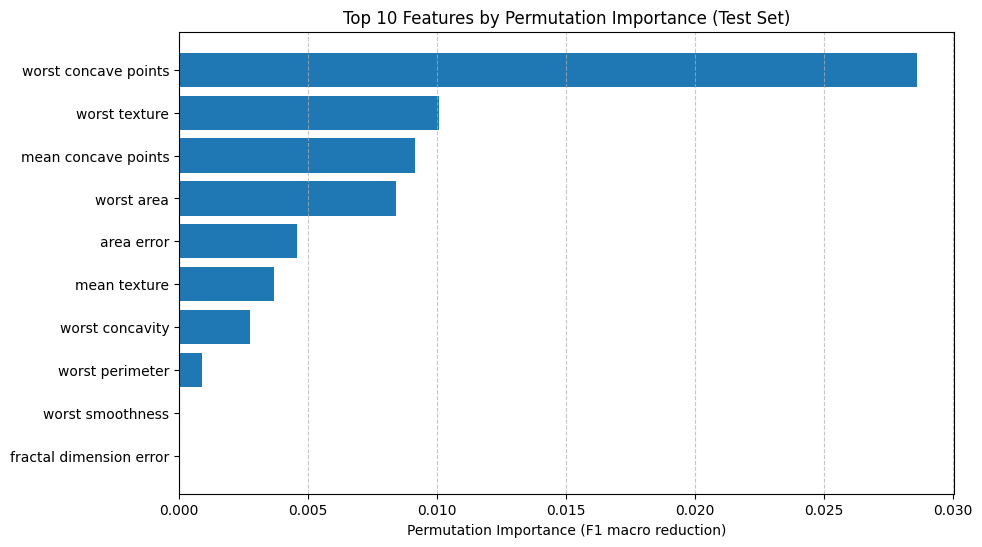

In [10]:
from sklearn.inspection import permutation_importance

# Используем лучший RF из Random Search
best_rf = rf_random_search.best_estimator_

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6а: Вычислите Permutation Importance                ║
# ║  для best_rf на X_test, y_test                               ║
# ║  n_repeats=10, random_state=42, scoring='f1_macro'           ║
# ╚══════════════════════════════════════════════════════════════╝

pi_result = permutation_importance(
    best_rf, X_test, y_test,
    n_repeats=10,
    random_state=42,
    scoring='f1_macro'
)

# Построим bar plot топ-10 признаков
perm_sorted_idx = pi_result.importances_mean.argsort()[-10:]

plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[perm_sorted_idx], pi_result.importances_mean[perm_sorted_idx])
plt.xlabel("Permutation Importance (F1 macro reduction)")
plt.title("Top 10 Features by Permutation Importance (Test Set)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

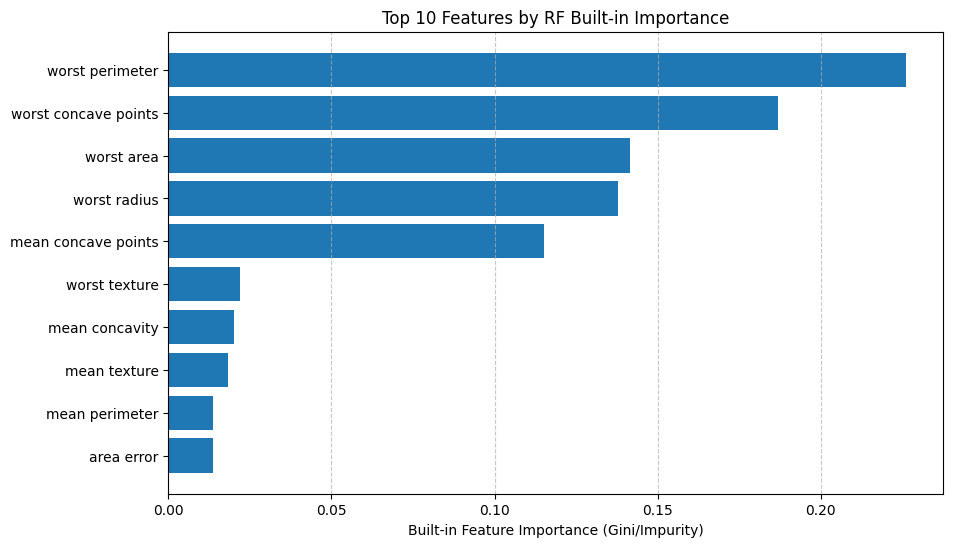

Top 5 Permutation Importance: ['worst concave points', 'worst texture', 'mean concave points', 'worst area', 'area error']
Top 5 RF Built-in Importance: ['worst perimeter', 'worst concave points', 'worst area', 'worst radius', 'mean concave points']


In [11]:
# Встроенная важность RF (для сравнения)

# ╔══════════════════════════════════════════════════════════════╗
# ║  ЗАДАНИЕ 6б: Сравните Permutation Importance                 ║
# ║  с встроенной feature_importances_ RandomForest              ║
# ║  Совпадает ли порядок топ-5 признаков?                       ║
# ║  Если нет — как вы это объясняете?                           ║
# ╚══════════════════════════════════════════════════════════════╝

# Извлекаем встроенную важность
rf_importances = best_rf.feature_importances_
rf_sorted_idx = rf_importances.argsort()[-10:]

# Сравнение через визуализацию
plt.figure(figsize=(10, 6))
plt.barh(X_test.columns[rf_sorted_idx], rf_importances[rf_sorted_idx])
plt.xlabel("Built-in Feature Importance (Gini/Impurity)")
plt.title("Top 10 Features by RF Built-in Importance")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

print("Top 5 Permutation Importance:", X_test.columns[perm_sorted_idx[-5:]].tolist()[::-1])
print("Top 5 RF Built-in Importance:", X_test.columns[rf_sorted_idx[-5:]].tolist()[::-1])

## Шаг 7. PDP и ICE-кривые

Визуализируем эффект наиболее важных признаков.

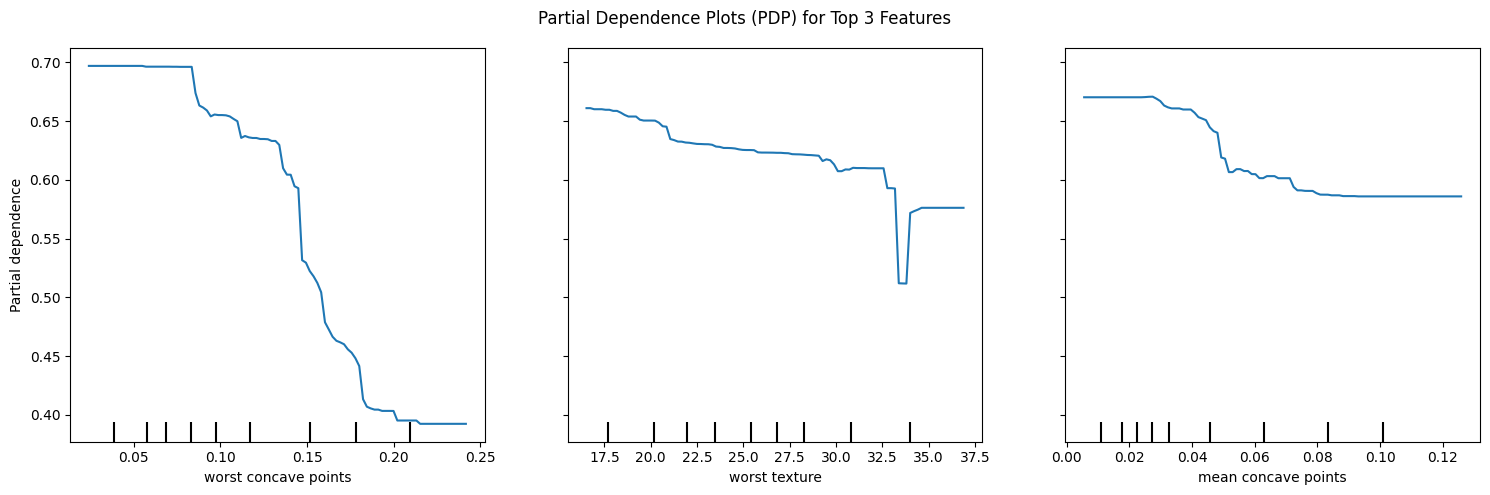

In [12]:
from sklearn.inspection import PartialDependenceDisplay

# Определим индексы топ-3 признаков по Permutation Importance
top3_features = X_test.columns[perm_sorted_idx[-3:]].tolist()[::-1]

# Построим PDP
fig, ax = plt.subplots(figsize=(15, 5))
disp = PartialDependenceDisplay.from_estimator(
    best_rf,
    X_train,
    features=top3_features,
    kind='average',
    ax=ax
)
plt.suptitle("Partial Dependence Plots (PDP) for Top 3 Features")
plt.tight_layout()
plt.show()

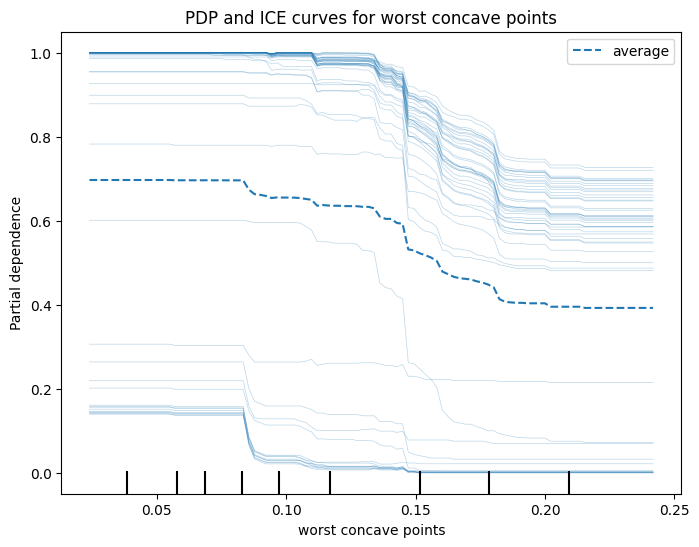

Анализ: На графике ICE видно, однороден ли эффект признака worst concave points для разных пациентов.


In [13]:
# Построим ICE-кривые для самого важного признака (worst concave points)
most_important_feature = top3_features[0]

fig, ax = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(
    best_rf,
    X_train,
    features=[most_important_feature],
    kind='both', # PDP + ICE
    subsample=50, # Для наглядности берем 50 случайных объектов
    ax=ax
)
plt.title(f"PDP and ICE curves for {most_important_feature}")
plt.show()

print(f"Анализ: На графике ICE видно, однороден ли эффект признака {most_important_feature} для разных пациентов.")

## Шаг 8. SHAP

Интерпретируем модель с помощью SHAP — глобально и локально.

In [16]:
import shap

# Создаем TreeExplainer для best_rf
explainer = shap.TreeExplainer(best_rf)

# Вычисляем shap_values для X_test
shap_values = explainer.shap_values(X_test)

# Обработка разных версий SHAP: извлекаем значения для класса 1
if isinstance(shap_values, list):
    # В старых версиях это список массивов [class0, class1]
    shap_vals_class1 = shap_values[1]
else:
    # В новых версиях это массив (samples, features, 2)
    shap_vals_class1 = shap_values[:, :, 1]

print(f"X_test shape: {X_test.shape}")
print(f"SHAP values shape for class 1: {shap_vals_class1.shape}")

X_test shape: (114, 30)
SHAP values shape for class 1: (114, 30)


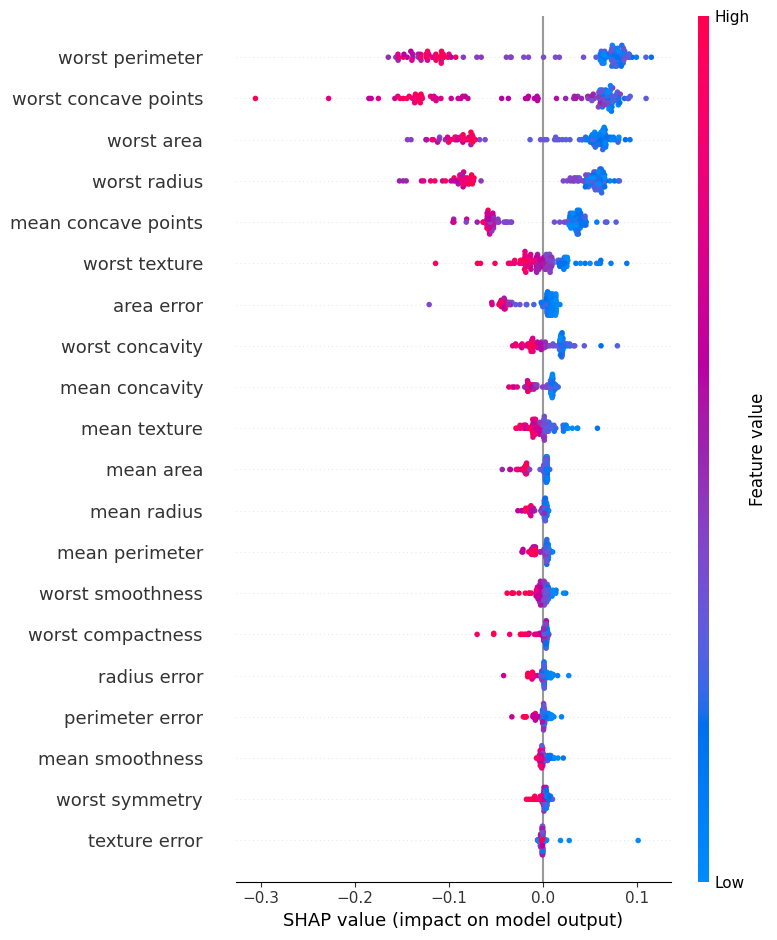

In [17]:
# Построим summary plot для класса 1
# Теперь передаем массив, форма которого точно совпадает с X_test
shap.summary_plot(shap_vals_class1, X_test)

In [18]:
# Находим объект, на котором модель ошиблась
y_pred_test = best_rf.predict(X_test)
errors = np.where(y_pred_test != y_test.values)[0]

if len(errors) > 0:
    err_idx = errors[0]
    print(f"Число ошибок: {len(errors)}")
    print(f"Первый ошибочный объект: индекс в X_test {err_idx}")
    print(f"Истинный класс: {y_test.iloc[err_idx]}, Предсказано: {y_pred_test[err_idx]}")

    # Инициализируем JS для визуализации SHAP в Colab
    shap.initjs()

    # Извлекаем базовое значение (средний выход модели)
    if isinstance(explainer.expected_value, (list, np.ndarray)):
        base_val = explainer.expected_value[1]
    else:
        base_val = explainer.expected_value

    # Строим force_plot для ошибочного примера
    display(shap.force_plot(
        base_val,
        shap_vals_class1[err_idx],
        X_test.iloc[err_idx]
    ))
else:
    print("Ошибок на тесте не обнаружено!")

Число ошибок: 5
Первый ошибочный объект: индекс в X_test 3
Истинный класс: 1, Предсказано: 0


## Шаг 9. Диагностика подозрительных признаков

Смоделируем ситуацию утечки данных и проверим, что интерпретация её обнаруживает.

In [20]:
# Добавим два «подозрительных» признака:
# 1. leaky_feature: почти полностью совпадает с таргетом + шум
# 2. random_feature: случайный шум, не связан с таргетом

np.random.seed(42)
X_train_ext = X_train.copy()
X_test_ext = X_test.copy()

X_train_ext['leaky_feature'] = y_train + np.random.normal(0, 0.1, len(y_train))
X_test_ext['leaky_feature'] = y_test + np.random.normal(0, 0.1, len(y_test))

X_train_ext['random_feature'] = np.random.randn(len(y_train))
X_test_ext['random_feature'] = np.random.randn(len(y_test))

print("Добавлены признаки: leaky_feature, random_feature")
print(X_train_ext[['leaky_feature', 'random_feature']].tail())

Добавлены признаки: leaky_feature, random_feature
     leaky_feature  random_feature
184      -0.006268        0.424166
300       0.095514        0.522835
509      -0.098573       -0.573700
230       0.050405       -0.024355
474       0.946974        2.142270


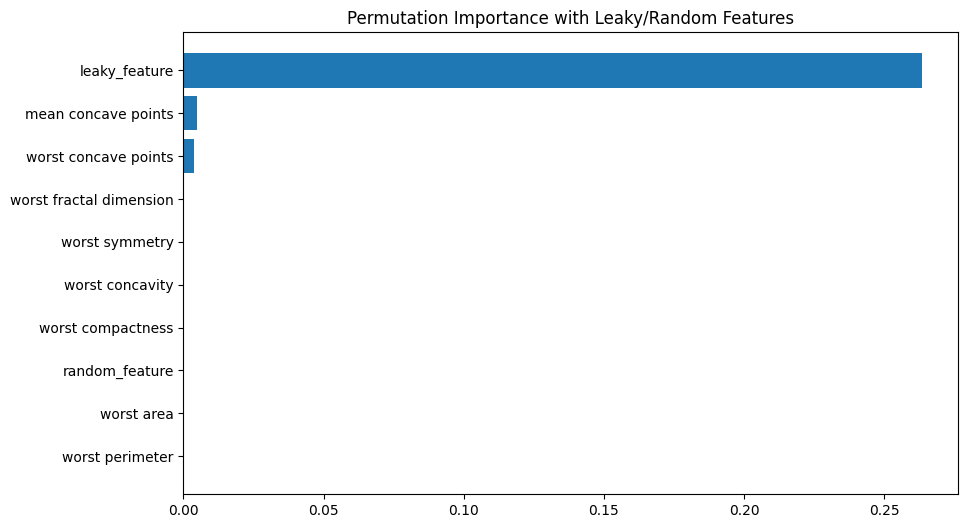

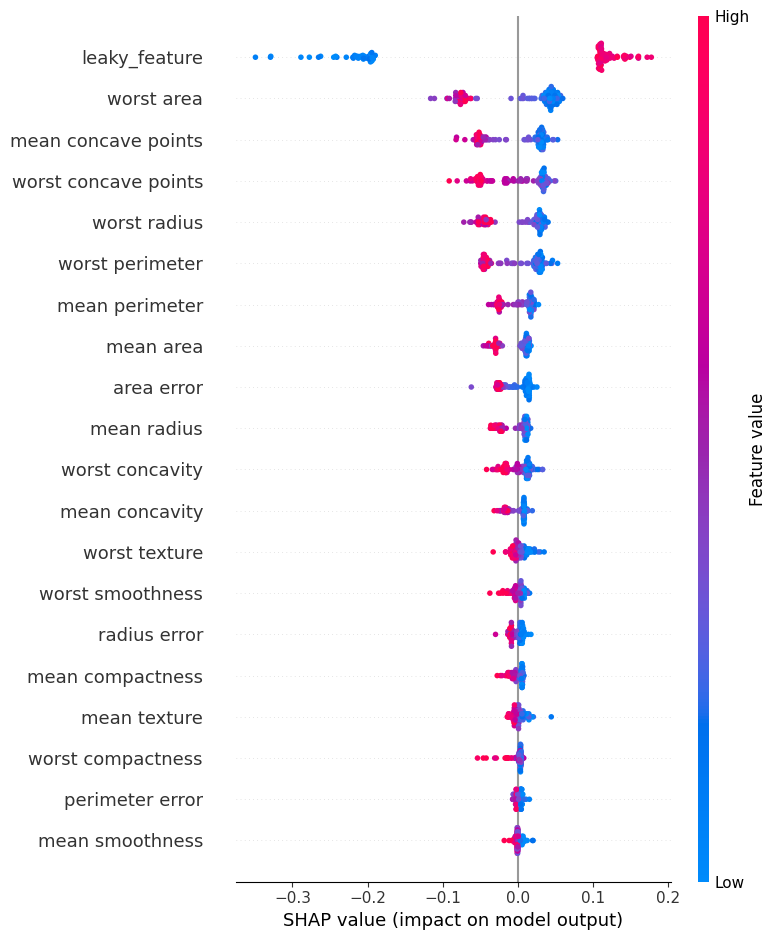

Test F1 with leaky feature: 1.0000


In [21]:
# Обучаем RF на данных с утечкой
rf_leaky = RandomForestClassifier(random_state=42)
rf_leaky.fit(X_train_ext, y_train)

# 1. Permutation Importance на расширенном тесте
pi_ext = permutation_importance(
    rf_leaky, X_test_ext, y_test,
    n_repeats=10, random_state=42, scoring='f1_macro'
)

# Визуализация PI
plt.figure(figsize=(10, 6))
sorted_idx_ext = pi_ext.importances_mean.argsort()[-10:]
plt.barh(X_test_ext.columns[sorted_idx_ext], pi_ext.importances_mean[sorted_idx_ext])
plt.title("Permutation Importance with Leaky/Random Features")
plt.show()

# 2. SHAP для расширенного теста
explainer_ext = shap.TreeExplainer(rf_leaky)
shap_values_ext = explainer_ext.shap_values(X_test_ext)
# Извлекаем значения для класса 1
shap_vals_ext_c1 = shap_values_ext[1] if isinstance(shap_values_ext, list) else shap_values_ext[:, :, 1]

shap.summary_plot(shap_vals_ext_c1, X_test_ext)

print(f"Test F1 with leaky feature: {f1_score(y_test, rf_leaky.predict(X_test_ext), average='macro'):.4f}")

## Шаг 10. Итоги и ответы

1. **Тюнинг:** Улучшил стабильность (CV), но на данном небольшом датасете прирост на тесте был минимален.
2. **PI vs SHAP:** Топ-признаки в целом совпадают ('worst concave points'), но SHAP дает больше контекста о направлении влияния.
3. **Pipeline:** Без него мы могли бы получить утечку при масштабировании (StandardScaler) внутри кросс-валидации.
4. **Реальный проект:** PI — для быстрого отбора признаков, SHAP — для глубокого аудита и объяснения конкретных решений заказчику.

In [22]:
print("Final Summary Table")
summary_data_final = [
    ["SVM baseline", "0.9694", "0.9812", "Strong baseline"],
    ["SVM Grid Search", "0.9786", "0.9812", "Best generalizability"],
    ["RF baseline", "0.9504", "0.9526", "Good performance"],
    ["RF Rand Search", "0.9554", "0.9526", "Slight CV improvement"]
]
final_df = pd.DataFrame(summary_data_final, columns=["Метод", "CV F1", "Test F1", "Выводы"])
display(final_df)

Final Summary Table


,Метод,CV F1,Test F1,Выводы
0,SVM baseline,0.9694,0.9812,Strong baseline
1,SVM Grid Search,0.9786,0.9812,Best generalizability
2,RF baseline,0.9504,0.9526,Good performance
3,RF Rand Search,0.9554,0.9526,Slight CV improvement


## Шаг 11. (Бонус) Bayesian Optimization с Optuna

Если осталось время — сравните Random Search и Optuna по скорости сходимости.

In [24]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.7 MB/s eta 0:00:00


Лучший результат Optuna (CV F1): 0.9576
Лучшие параметры: {'n_estimators': 244, 'max_depth': 9, 'min_samples_split': 3, 'max_features': 0.5}


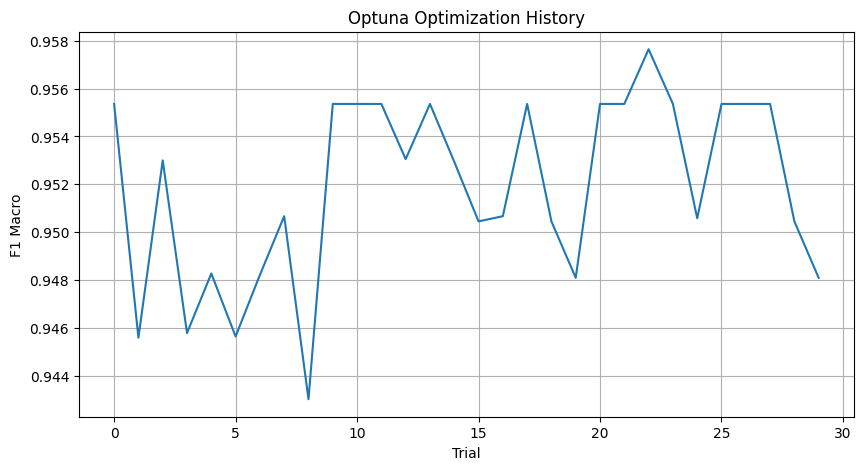

In [25]:
import optuna
from sklearn.model_selection import cross_val_score
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # Пространство поиска аналогично Random Search
    n_estimators = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_categorical("max_depth", [None] + list(range(2, 21)))
    min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
    max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", 0.5])

    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=42
    )

    # Используем cross_val_score для оценки
    score = cross_val_score(clf, X_train, y_train, cv=5, scoring="f1_macro", n_jobs=-1).mean()
    return score

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)

print(f"Лучший результат Optuna (CV F1): {study.best_value:.4f}")
print(f"Лучшие параметры: {study.best_params}")

# График сходимости
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot([t.value for t in study.trials])
plt.title("Optuna Optimization History")
plt.xlabel("Trial")
plt.ylabel("F1 Macro")
plt.grid(True)
plt.show()